In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
out_dir = "/nfs/turbo/umms-lgarmire/home/yhdu/Bowei_NAS/EFIGA/Review/AD_RnT/Pseduotime/figs_2nd_modify/"

assoc_df = pd.read_csv("/nfs/turbo/umms-lgarmire/home/yhdu/Bowei_NAS/EFIGA/Review/AD_RnT/Pseduotime/figs_2nd_modify/MONOCLE_assoc_df.csv")
heatmap_df  = pd.read_csv('/nfs/turbo/umms-lgarmire/home/yhdu/Bowei_NAS/EFIGA/Review/AD_RnT/Pseduotime/figs_2nd_modify/MONOCLE_assoc_df_r2_0.5.csv')

In [3]:
heatmap_df 

,Unnamed: 0,EMCI1->EMCI2,EMCI1->LMCI1,EMCI1->LMCI2
0,HMDB0000651,0.382861,0.466542,0.497157
1,HMDB0002250,0.407586,0.484179,0.522855
2,HMDB13330,0.314092,0.418033,0.468080
3,HMDB13331,0.438911,0.509458,0.541133
4,HMDB13332,0.412904,0.482718,0.516605
5,HMDB0000201,0.238559,0.276792,0.314374
6,HMDB0000791,0.402797,0.479417,0.501917


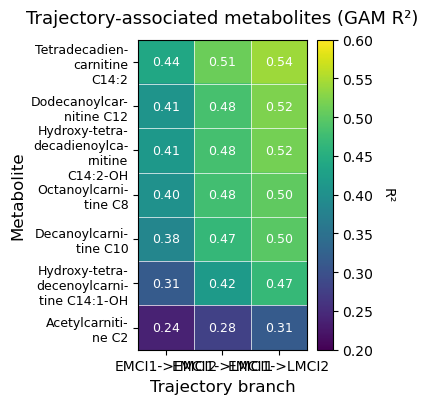

In [6]:
import textwrap

def hyphen_wrap(text, width=14):
    tokens = []
    for word in text.split():
        while len(word) > width:
            tokens.append(word[:width-1] + '-')
            word = word[width-1:]
        tokens.append(word)
    return textwrap.fill(' '.join(tokens), width)

# ── Load and force numeric ─────────────────────────────────────────
heatmap_df = pd.read_csv(
    '/nfs/turbo/umms-lgarmire/home/yhdu/Bowei_NAS/EFIGA/Review/AD_RnT/Pseduotime/figs_2nd_modify/MONOCLE_assoc_df_r2_0.5.csv',
    index_col=0
)
heatmap_df = heatmap_df.apply(pd.to_numeric, errors='coerce')  # drop any stray string columns

# ── Metabolite names ───────────────────────────────────────────────
metabolite_map = {
    "HMDB0000651": "Decanoylcarnitine C10",
    "HMDB0002250": "Dodecanoylcarnitine C12",
    "HMDB13330":   "Hydroxy-tetradecenoylcarnitine C14:1-OH",
    "HMDB13331":   "Tetradecadiencarnitine C14:2",
    "HMDB13332":   "Hydroxy-tetradecadienoylcarnitine C14:2-OH",
    "HMDB0000201": "Acetylcarnitine C2",
    "HMDB0000791": "Octanoylcarnitine C8",
}

module_map = {
    "HMDB0002250": "Acylcarnitine / FAO",
    "HMDB0000651": "Acylcarnitine / FAO",
    "HMDB13330":   "Acylcarnitine / FAO",
    "HMDB13331":   "Acylcarnitine / FAO",
    "HMDB0000791": "Acylcarnitine / FAO",
    "HMDB13332":   "Hydroxy-acylcarnitine / incomplete FAO",
    "HMDB0000870": "Histidine–histamine / neuroimmune",
    "HMDB0000177": "Histidine–histamine / neuroimmune",
    "HMDB0000517": "Amino acid / nitrogen",
    "HMDB0000641": "Amino acid / nitrogen",
    "HMDB0000201": "Amino acid / nitrogen",
    "HMDB0000696": "One-carbon / methylation",
}

module_order = [
    "Acylcarnitine / FAO",
    "Hydroxy-acylcarnitine / incomplete FAO",
    "Histidine–histamine / neuroimmune",
    "Amino acid / nitrogen",
    "One-carbon / methylation",
    "Other",
]

# ── Map HMDB index to metabolite names ────────────────────────────
heatmap_df.index = heatmap_df.index.map(lambda x: metabolite_map.get(x, x))

# Read HMDB IDs BEFORE remapping index
hmdb_ids = heatmap_df.index.tolist()

# Now remap index to metabolite names
heatmap_df.index = heatmap_df.index.map(lambda x: metabolite_map.get(x, x))

# Order rows
module_series = pd.Categorical(
    [module_map.get(h, "Other") for h in hmdb_ids],
    categories=module_order, ordered=True
)
order_df = pd.DataFrame({
    "Label":  heatmap_df.index,
    "Module": module_series,
    "MaxR2":  heatmap_df.max(axis=1).values   # now numeric, no error
}).sort_values(["Module", "MaxR2"], ascending=[True, False])

heatmap_df = heatmap_df.reindex(order_df["Label"])


# ── Column order ───────────────────────────────────────────────────
col_order = ["EMCI1->EMCI2", "EMCI1->LMCI1", "EMCI1->LMCI2"]
col_order = [c for c in col_order if c in heatmap_df.columns]
heatmap_df = heatmap_df[col_order]

matrix = np.ma.masked_invalid(heatmap_df.values.astype(float))

# ── Plot ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(4, max(4, len(heatmap_df) * 0.45 + 1)))

im = ax.imshow(matrix, aspect="auto", cmap="viridis", vmin=0.2, vmax=0.6)

ax.set_xticks(np.arange(len(heatmap_df.columns)))
ax.set_xticklabels(heatmap_df.columns, rotation=0, ha="center", fontsize=10)
ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels([hyphen_wrap(lbl, 14) for lbl in heatmap_df.index], fontsize=9)
ax.set_xlabel("Trajectory branch", fontsize=12)
ax.set_ylabel("Metabolite", fontsize=12)
ax.set_title("Trajectory-associated metabolites (GAM R²)", fontsize=13, pad=12)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        val = heatmap_df.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                    fontsize=9, color="white" if val >= 0.3 else "white")

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("R²", rotation=270, labelpad=15)

ax.set_xticks(np.arange(-0.5, len(heatmap_df.columns), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(heatmap_df.index), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.5)
ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()
plt.savefig(f"/nfs/turbo/umms-lgarmire/home/yhdu/Bowei_NAS/EFIGA/Review/AD_RnT/Pseduotime/monocle_gam_heatmap.png", dpi=300, bbox_inches="tight")
#plt.savefig(f"{out_dir}/monocle_gam_heatmap.pdf", bbox_inches="tight")
plt.show()